# SIM 504 — Secondary Mesh Convergence

For each deformation measure (w_mean, w_std, w_cv, w_std_area_weighted, w_cv_area_weighted, W, eta, shear_mean, gle_mean, edi_mean) this notebook produces **two plots**:
- **Triangular secondary meshes**: T2_001 … T2_004 overlaid on the same axes
- **Quad secondary meshes**: Q2_001 … Q2_005 overlaid on the same axes

X-axis: displacement (−U2 at PERN-9999997) from `DATA_PICK_504_A2.pkl`  
Y-axis: the measure evaluated on the secondary mesh at each load step.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'Z001_Results_Analizer':
    ROOT = ROOT.parent
RESULTS = ROOT / 'I001_Results'

SIM = 504
LOAD_KEY = (1, 1, 2, 2)   # load-case key used in the video properties


In [2]:
# ── Load x-axis: displacement from A2 file ────────────────────────────────────
with (RESULTS / f'DATA_PICK_{SIM}_A2.pkl').open('rb') as f:
    A2 = pickle.load(f)

disp = -np.array(A2['U2']['PERN-9999997'])   # positive compression
print(f'Displacement array: {len(disp)} steps, range [{disp.min():.3f}, {disp.max():.3f}] mm')


Displacement array: 201 steps, range [-0.192, 5.000] mm


In [3]:
# ── Load secondary mesh pickle files ─────────────────────────────────────────
def load_secondary(prefix, indices):
    """
    Load a list of secondary mesh pickle files.
    Returns list of (label, data_dict) tuples for files that exist.
    prefix : e.g. 'T2'  →  DATA_PICK_504_T2_001.pkl
    indices: list of int, e.g. [1,2,3,4]
    """
    loaded = []
    for i in indices:
        path = RESULTS / f'DATA_PICK_{SIM}_{prefix}_{i:03d}.pkl'
        if not path.exists():
            print(f'  {path.name}: NOT FOUND — skipped')
            continue
        with path.open('rb') as f:
            d = pickle.load(f)
        n_el = d['general_information']['n_elements']
        label = f'{prefix}_{i:03d}  ({n_el} elements)'
        loaded.append((label, d))
        print(f'  {path.name}: {n_el} elements  source: {d["source_file"]}')
    return loaded

print('Triangular secondary meshes:')
TRI = load_secondary('T2', [1, 2, 3, 4, 5])
print()
print('Quad secondary meshes:')
QUAD = load_secondary('Q2', [1, 2, 3, 4, 5])


Triangular secondary meshes:
  DATA_PICK_504_T2_001.pkl: 324 elements  source: C001_Mesh_files/R030_080k_T001.tri
  DATA_PICK_504_T2_002.pkl: 576 elements  source: C001_Mesh_files/R030_080k_T002.tri
  DATA_PICK_504_T2_003.pkl: 900 elements  source: C001_Mesh_files/R030_080k_T003.tri
  DATA_PICK_504_T2_004.pkl: 1600 elements  source: C001_Mesh_files/R030_080k_T004.tri
  DATA_PICK_504_T2_005.pkl: NOT FOUND — skipped

Quad secondary meshes:
  DATA_PICK_504_Q2_001.pkl: 81 elements  source: C001_Mesh_files/R030_080k_Q001.quad
  DATA_PICK_504_Q2_002.pkl: 144 elements  source: C001_Mesh_files/R030_080k_Q002.quad
  DATA_PICK_504_Q2_003.pkl: 225 elements  source: C001_Mesh_files/R030_080k_Q003.quad
  DATA_PICK_504_Q2_004.pkl: 400 elements  source: C001_Mesh_files/R030_080k_Q004.quad
  DATA_PICK_504_Q2_005.pkl: 729 elements  source: C001_Mesh_files/R030_080k_Q005.quad


In [5]:
# ── Plotting helpers ──────────────────────────────────────────────────────────
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

def _get(d, key, subkey=None):
    """Safely retrieve a field; returns np.array or None."""
    val = d.get(key)
    if val is None:
        return None
    if subkey is not None:
        val = val.get(subkey) if isinstance(val, dict) else None
    if val is None:
        return None
    return np.array(val)


def plot_metric(datasets, disp_arr, key, subkey, ylabel, title_suffix=''):
    """
    Overlay curves for every dataset on a single axes.
    datasets : list of (label, dict)
    key      : top-level key in the pkl dict, e.g. 'w_mean'
    subkey   : second-level key or None, e.g. (1,1,2,2)
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for i, (label, d) in enumerate(datasets):
        y = _get(d, key, subkey)
        if y is None:
            print(f'  [{label}] key {key}/{subkey} not found — skipped')
            continue
        # align lengths with displacement array
        n = min(len(disp_arr), len(y))
        ax.plot(disp_arr[:n], y[:n], color=COLORS[i % len(COLORS)],
                linewidth=1.6, label=label)
    ax.set_xlabel('Displacement [mm]')
    ax.set_ylabel(ylabel)
    ax.set_title(f'SIM {SIM} — {ylabel}{title_suffix}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_pair(key, subkey, ylabel):
    """Produce the TRI plot then the QUAD plot for one metric."""
    print(f'\n{"="*60}')
    print(f'  {ylabel}')
    print('='*60)
    plot_metric(TRI,  disp, key, subkey, ylabel, title_suffix=' — Triangular secondary mesh')
    plot_metric(QUAD, disp, key, subkey, ylabel, title_suffix=' — Quad secondary mesh')


## 1. w mean


  w mean


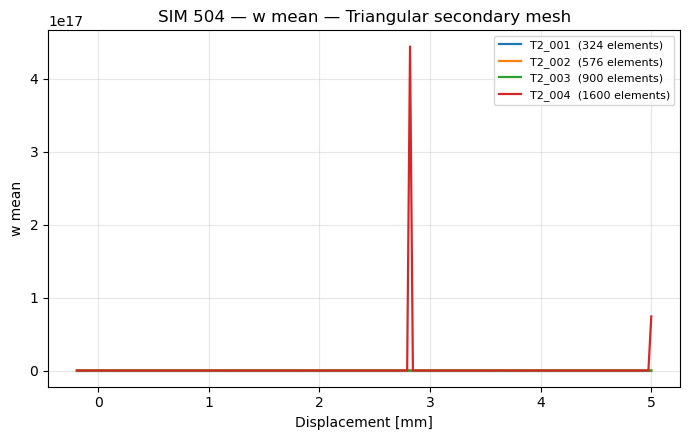

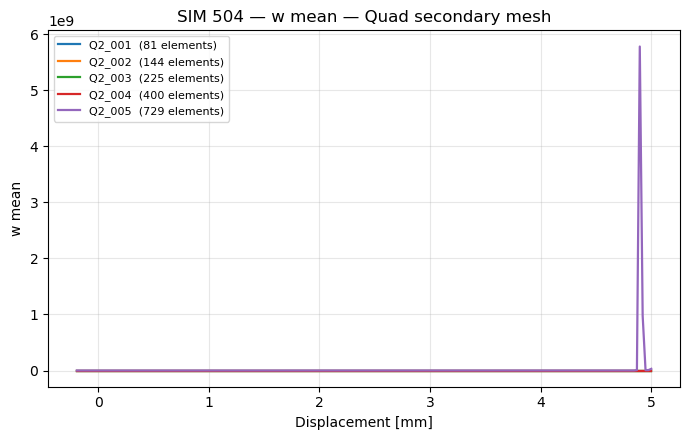

In [6]:
plot_pair('w_mean', LOAD_KEY, 'w mean')


## 2. w std


  w std


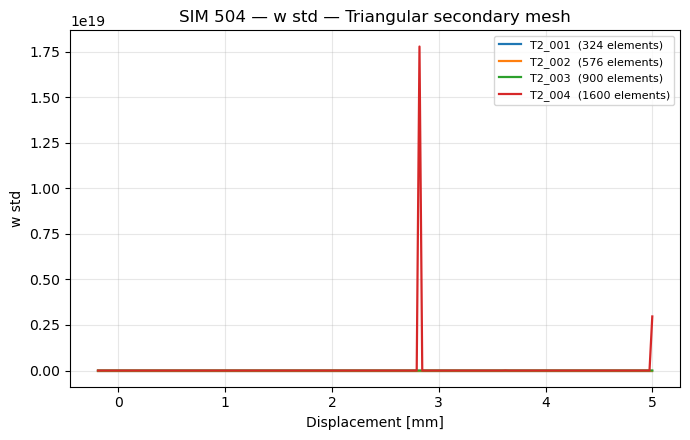

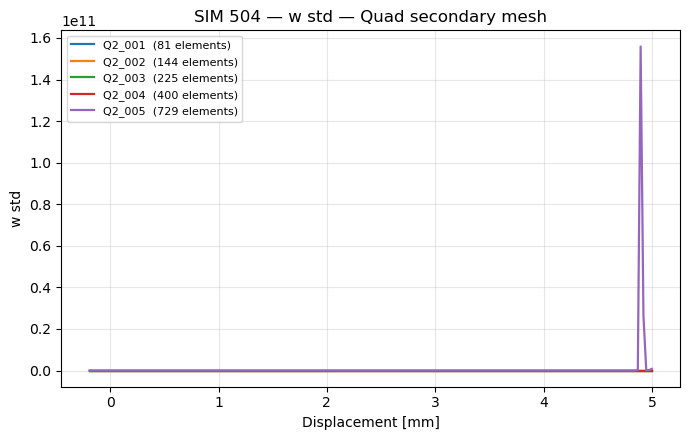

In [7]:
plot_pair('w_std', LOAD_KEY, 'w std')


## 3. w CV


  w CV


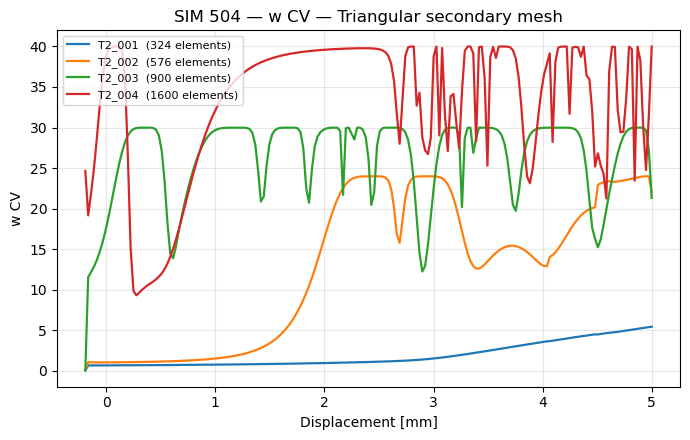

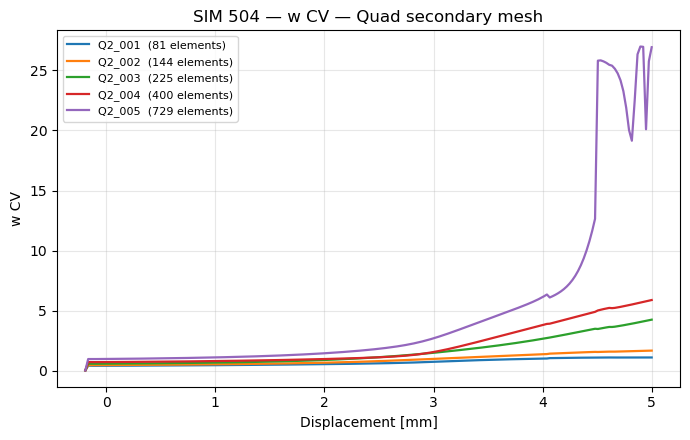

In [8]:
plot_pair('w_cv', LOAD_KEY, 'w CV')


## 4. w std area-weighted


  w std area-weighted


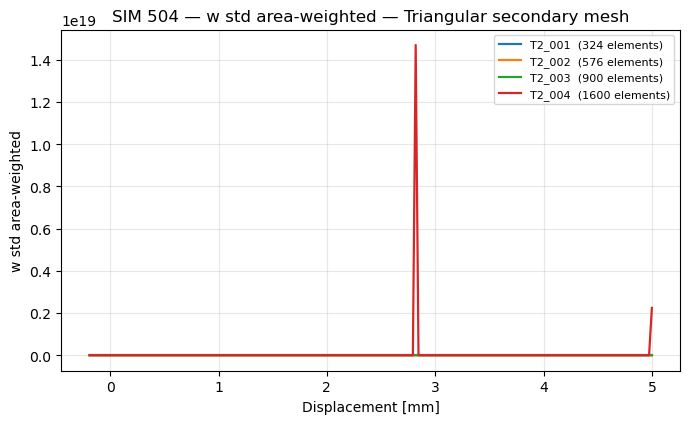

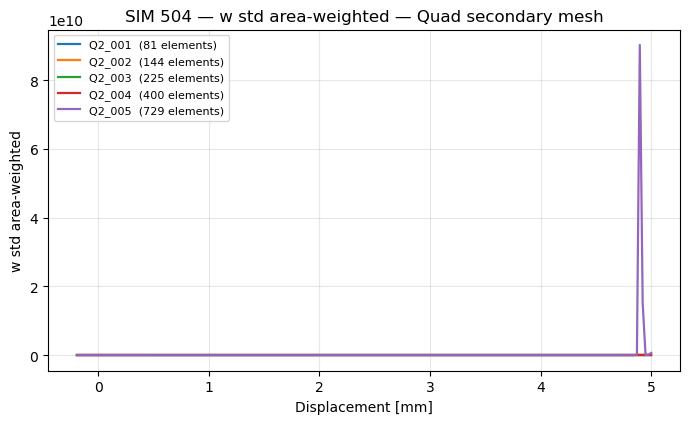

In [9]:
plot_pair('w_std_area_weighted', LOAD_KEY, 'w std area-weighted')


## 5. w CV area-weighted


  w CV area-weighted


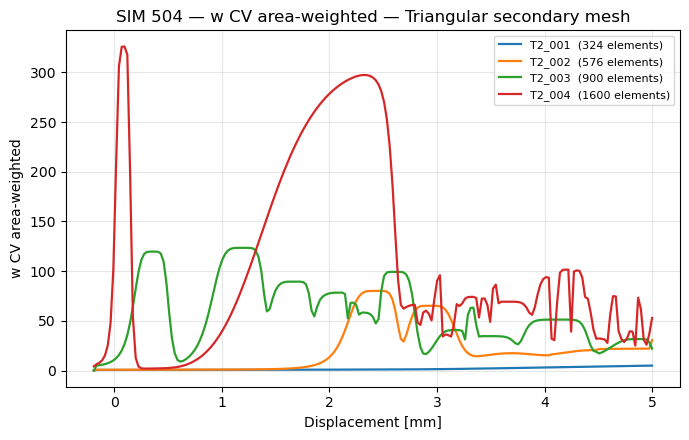

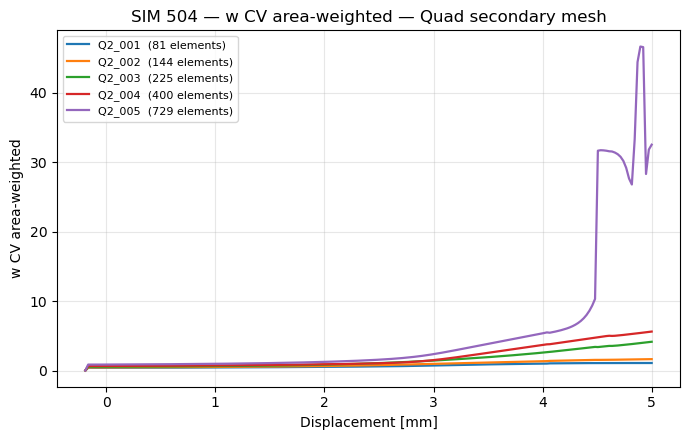

In [10]:
plot_pair('w_cv_area_weighted', LOAD_KEY, 'w CV area-weighted')


## 6. W — total energy


  W (total energy)


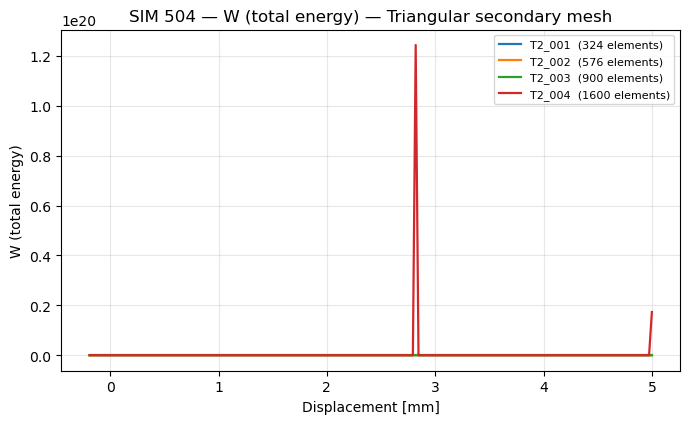

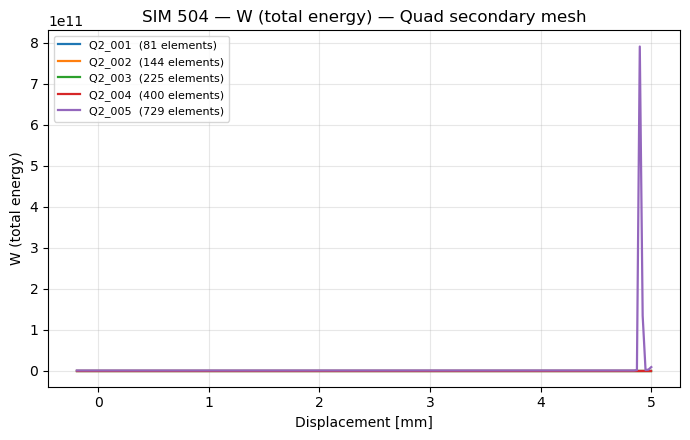

In [11]:
plot_pair('W', LOAD_KEY, 'W (total energy)')


## 7. eta — mesh regularity


  eta (mesh regularity)


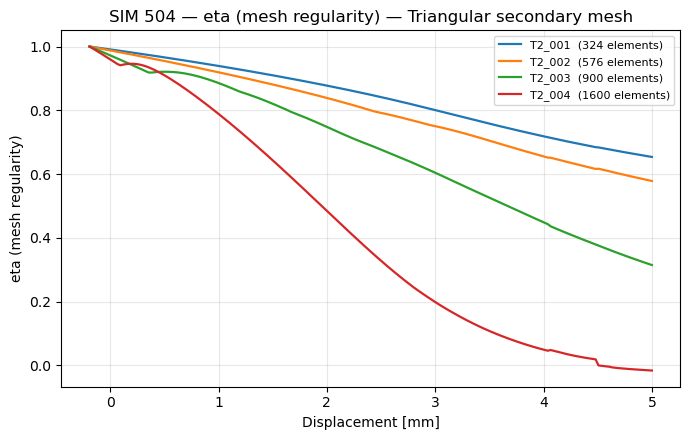

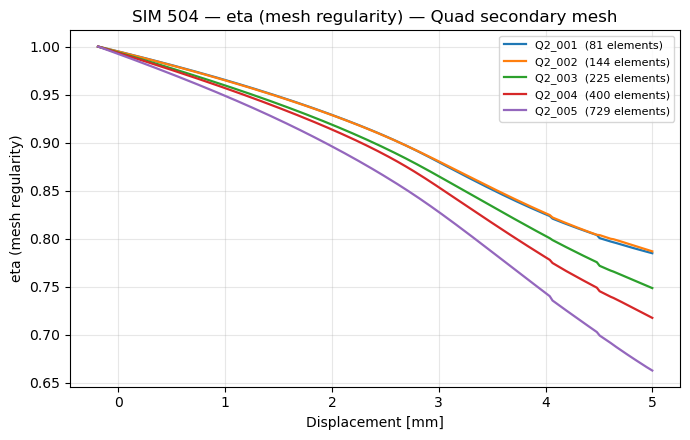

In [12]:
plot_pair('eta', None, 'eta (mesh regularity)')


## 8. shear mean


  shear mean


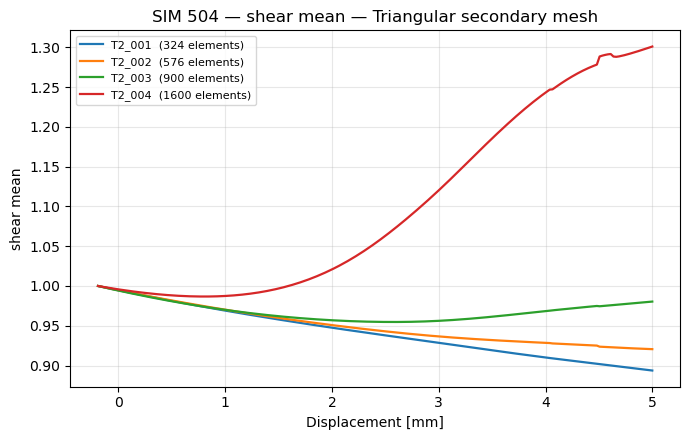

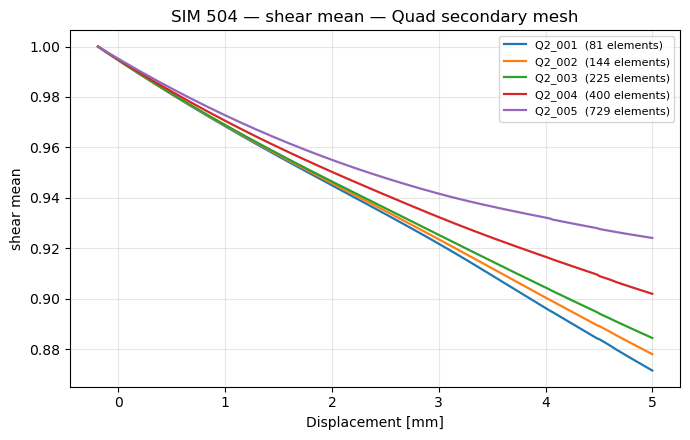

In [13]:
plot_pair('shear_mean', None, 'shear mean')


## 9. GLE mean


  GLE mean


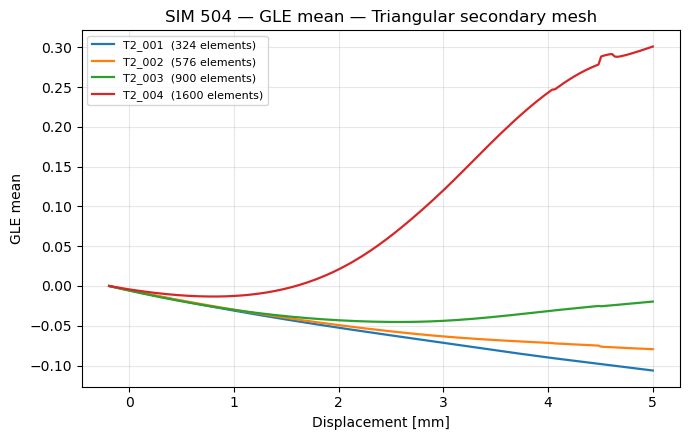

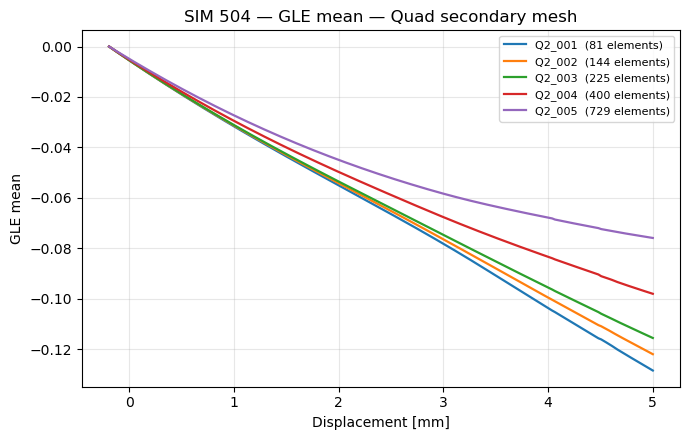

In [14]:
plot_pair('gle_mean', None, 'GLE mean')


## 10. EDI mean


  EDI mean


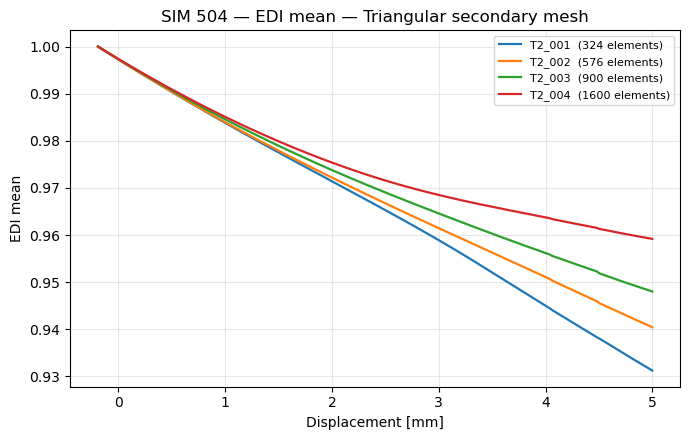

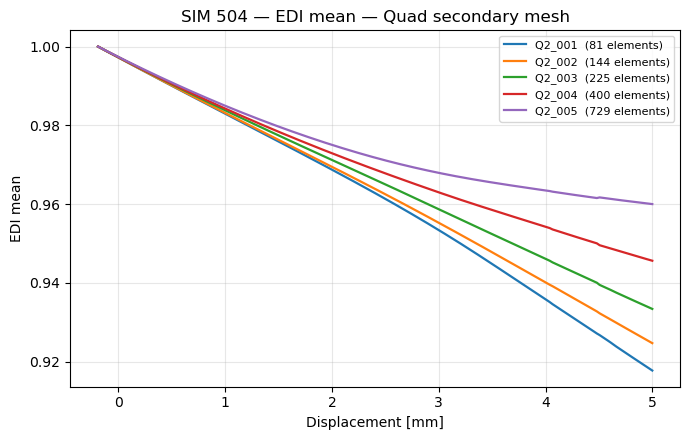

In [15]:
plot_pair('edi_mean', None, 'EDI mean')
